In [1]:
''' quantifying uncertainties in Neptune's shape as a function of those in occultation radii, gravity field, and rotation profile. '''

import matplotlib.pyplot as plt
plt.style.use(f'plots.mplstyle')
%config InlineBackend.figure_format = 'retina'

import numpy as np
from importlib import reload

import mcmc; reload(mcmc)
import wind_profiles; reload(wind_profiles)

wind_options = {
    'voyager':{
        'color':plt.get_cmap('cividis')(1. / 8),
        'label':"Voyager",
    },
    'h-band 2014':{
        'color':plt.get_cmap('cividis')(7. / 8),
        'label':"T18 H-band 2014",
    },
}

# constants for Neptune; Jacobson 2009
r_ref = 25225e5
jn = 3408.43e-6, -33.4e-6, 0. # for reference, j2 and j4 uncertainties are 4.5e-6 and 2.9e-6
gm = 6836527e15

In [ ]:
''' experiment 1: fit r_pol to occultations for two fixed wind profiles '''

samplers = {}
for wind_option, _ in wind_options.items():

    # get a callable omega(phi) from chosen wind profile
    omega = wind_profiles.neptune_omega_tot_interpolant(option=wind_option)

    # create starting position for emcee sampler and check it has finite lnp
    ndim = 1 # one parameter: r_pol
    nwalk = 4 * ndim

    theta0 = (np.ones(nwalk) + 1e-2 * np.random.rand(nwalk)) * 2.5e9
    theta0 = theta0.reshape(nwalk, ndim)
    print('starting position:')
    print(theta0)

    print('starting lnp:')
    for iw, theta in enumerate(theta0):
        lnp, blob = mcmc.lnp(theta, jn, r_ref, gm, omega, debug=True, planet='neptune') # must pass planet to express which occs to compare to
        assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]:.5f}'
        print(lnp)

    import emcee
    from multiprocessing import Pool

    print('sampling:')
    # nsteps = 100 # testing
    # nsteps = 1000 # more exhaustive testing
    nsteps = 20000 # production
    with Pool() as pool:
        samplers[wind_option] = emcee.EnsembleSampler(
            nwalkers=nwalk,
            ndim=ndim,
            log_prob_fn=mcmc.lnp,
            pool=pool,
            args=(jn, r_ref, gm, omega),
            kwargs={'debug':True, 'planet':'neptune'},
        )

        samplers[wind_option].run_mcmc(
            initial_state=theta0,
            nsteps=nsteps,
            progress=True,
        )


starting position:
[[2.51061799e+09]
 [2.52228076e+09]
 [2.50317122e+09]
 [2.50993860e+09]]
starting lnp:
-14519.290562899874
-18952.805044320947
-11998.261632208556
-14279.296571229377
sampling:


100%|██████████| 20000/20000 [11:48<00:00, 28.23it/s]


starting position:
[[2.51966763e+09]
 [2.51414941e+09]
 [2.51835871e+09]
 [2.51813244e+09]]
starting lnp:
-16747.27577970266
-14719.838022881828
-16254.492538740311
-16170.053082719769
sampling:


100%|██████████| 20000/20000 [08:18<00:00, 40.09it/s]


In [4]:
import dill as pickle
with open('/Users/cmankovi/geoid_output/neptune_experiment1.pkl', 'rb') as fr:
    samplers = pickle.load(fr)

starting position:
[[ 2.51742469e+09  3.40849190e-03 -3.34004574e-05]
 [ 2.51877414e+09  3.40843466e-03 -3.34004216e-05]
 [ 2.51345653e+09  3.40843761e-03 -3.34000897e-05]
 [ 2.50728761e+09  3.40850414e-03 -3.34002122e-05]
 [ 2.51109752e+09  3.40848667e-03 -3.34001376e-05]
 [ 2.51730241e+09  3.40849585e-03 -3.34001135e-05]]
starting lnp:
-1141305.184216161
-1143082.828724564
-1141010.8737749192
-1137369.0457752766
-1139081.0407391055
-1141178.4527293548
sampling:


100%|██████████| 10000/10000 [06:01<00:00, 27.64it/s]


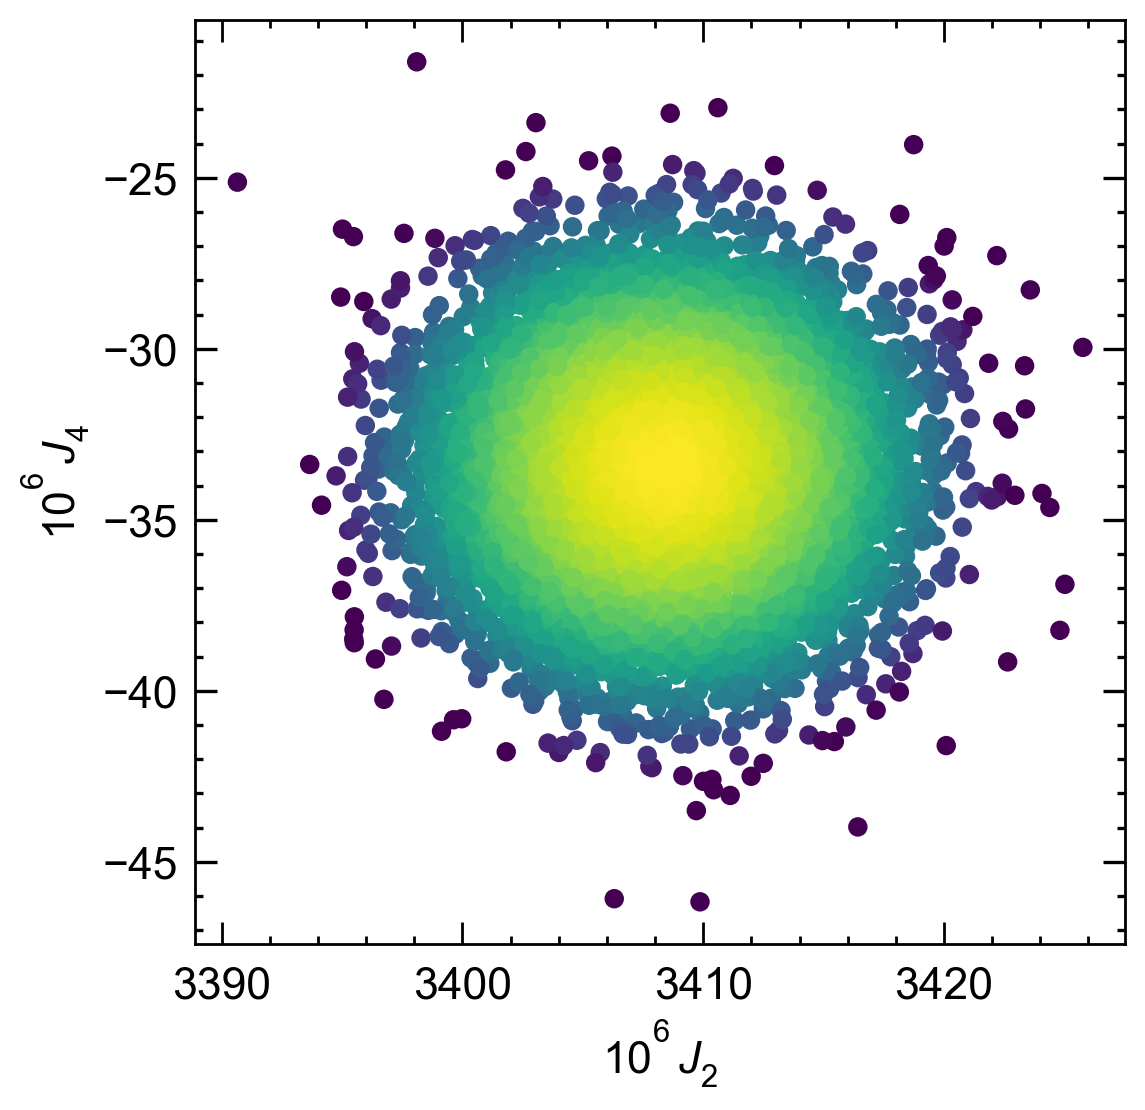

In [9]:
''' experiment 2: vary r_pol, j2, j4 with fixed voyager wind profile'''

# draw from j2-j4 prior distribution for display purposes
x = mcmc.gauss_jn_neptune.rvs(10000)
lnp = mcmc.gauss_jn_neptune.logpdf(x) - mcmc.gauss_jn_neptune.logpdf(mcmc.gauss_jn_neptune.mean)
plt.scatter(1e6 * x[:, 0], 1e6 * x[:, 1], c=lnp, vmin=-5)
plt.xlabel(r'$10^6\,J_2$')
plt.ylabel(r'$10^6\,J_4$')

omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager')

# create starting position for emcee sampler and check it has finite lnp
ndim = 3
nwalk = 2 * ndim

theta0 = np.zeros((nwalk, ndim))
theta0[:, 0] = 2.5e9 * (1. + np.random.rand(nwalk) * 1e-2) # r_pol # 1% spread around arbitrary starting guess
theta0[:, 1] = mcmc.gauss_jn_neptune.mean[0] * (1. + np.random.rand(nwalk) * mcmc.gauss_jn_neptune.cov[0, 0] ** 0.5 * 5) # j2 # uniform 5-sigma spread around measurement 
theta0[:, 2] = mcmc.gauss_jn_neptune.mean[1] * (1. + np.random.rand(nwalk) * mcmc.gauss_jn_neptune.cov[1, 1] ** 0.5 * 5) # j4 # uniform 5-sigma spread around measurement
print('starting position:')
print(theta0)

print('starting lnp:')
for iw, theta in enumerate(theta0):
    # lnp, blob = mcmc.lnp_prior_vary_jn(theta, r_ref, gm, omega, debug=True)
    lnp, blob = mcmc.lnp_vary_jn(theta, r_ref, gm, omega, debug=True, planet='neptune') # note jn are only passed as elements of theta: varied from model to model
    assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]:.5f}'
    print(lnp)

import emcee
from multiprocessing import Pool

print('sampling:')
# nsteps = 100
# nsteps = 1000
nsteps = 10000
with Pool() as pool:
    sampler_jn = emcee.EnsembleSampler(
        nwalkers=nwalk,
        ndim=ndim,
        log_prob_fn=mcmc.lnp_vary_jn,
        pool=pool, # comment out to do it serially. using multiprocessing.Pool is giving me ~37 it/s compared to ~22 it/s serially
        args=(r_ref, gm, omega),
        # kwargs={'debug':True,}
        kwargs={'debug':False,'sigma_rocc_km':0.05, 'planet':'neptune',} # make the RO uncertainty near-negligible at 50 meters to isolate the effect of the uncertain gravity field
    )

    sampler_jn.run_mcmc(
        initial_state=theta0,
        nsteps=nsteps,
        progress=True,
    )

vary jn: 24283.523 +/- 0.055 km


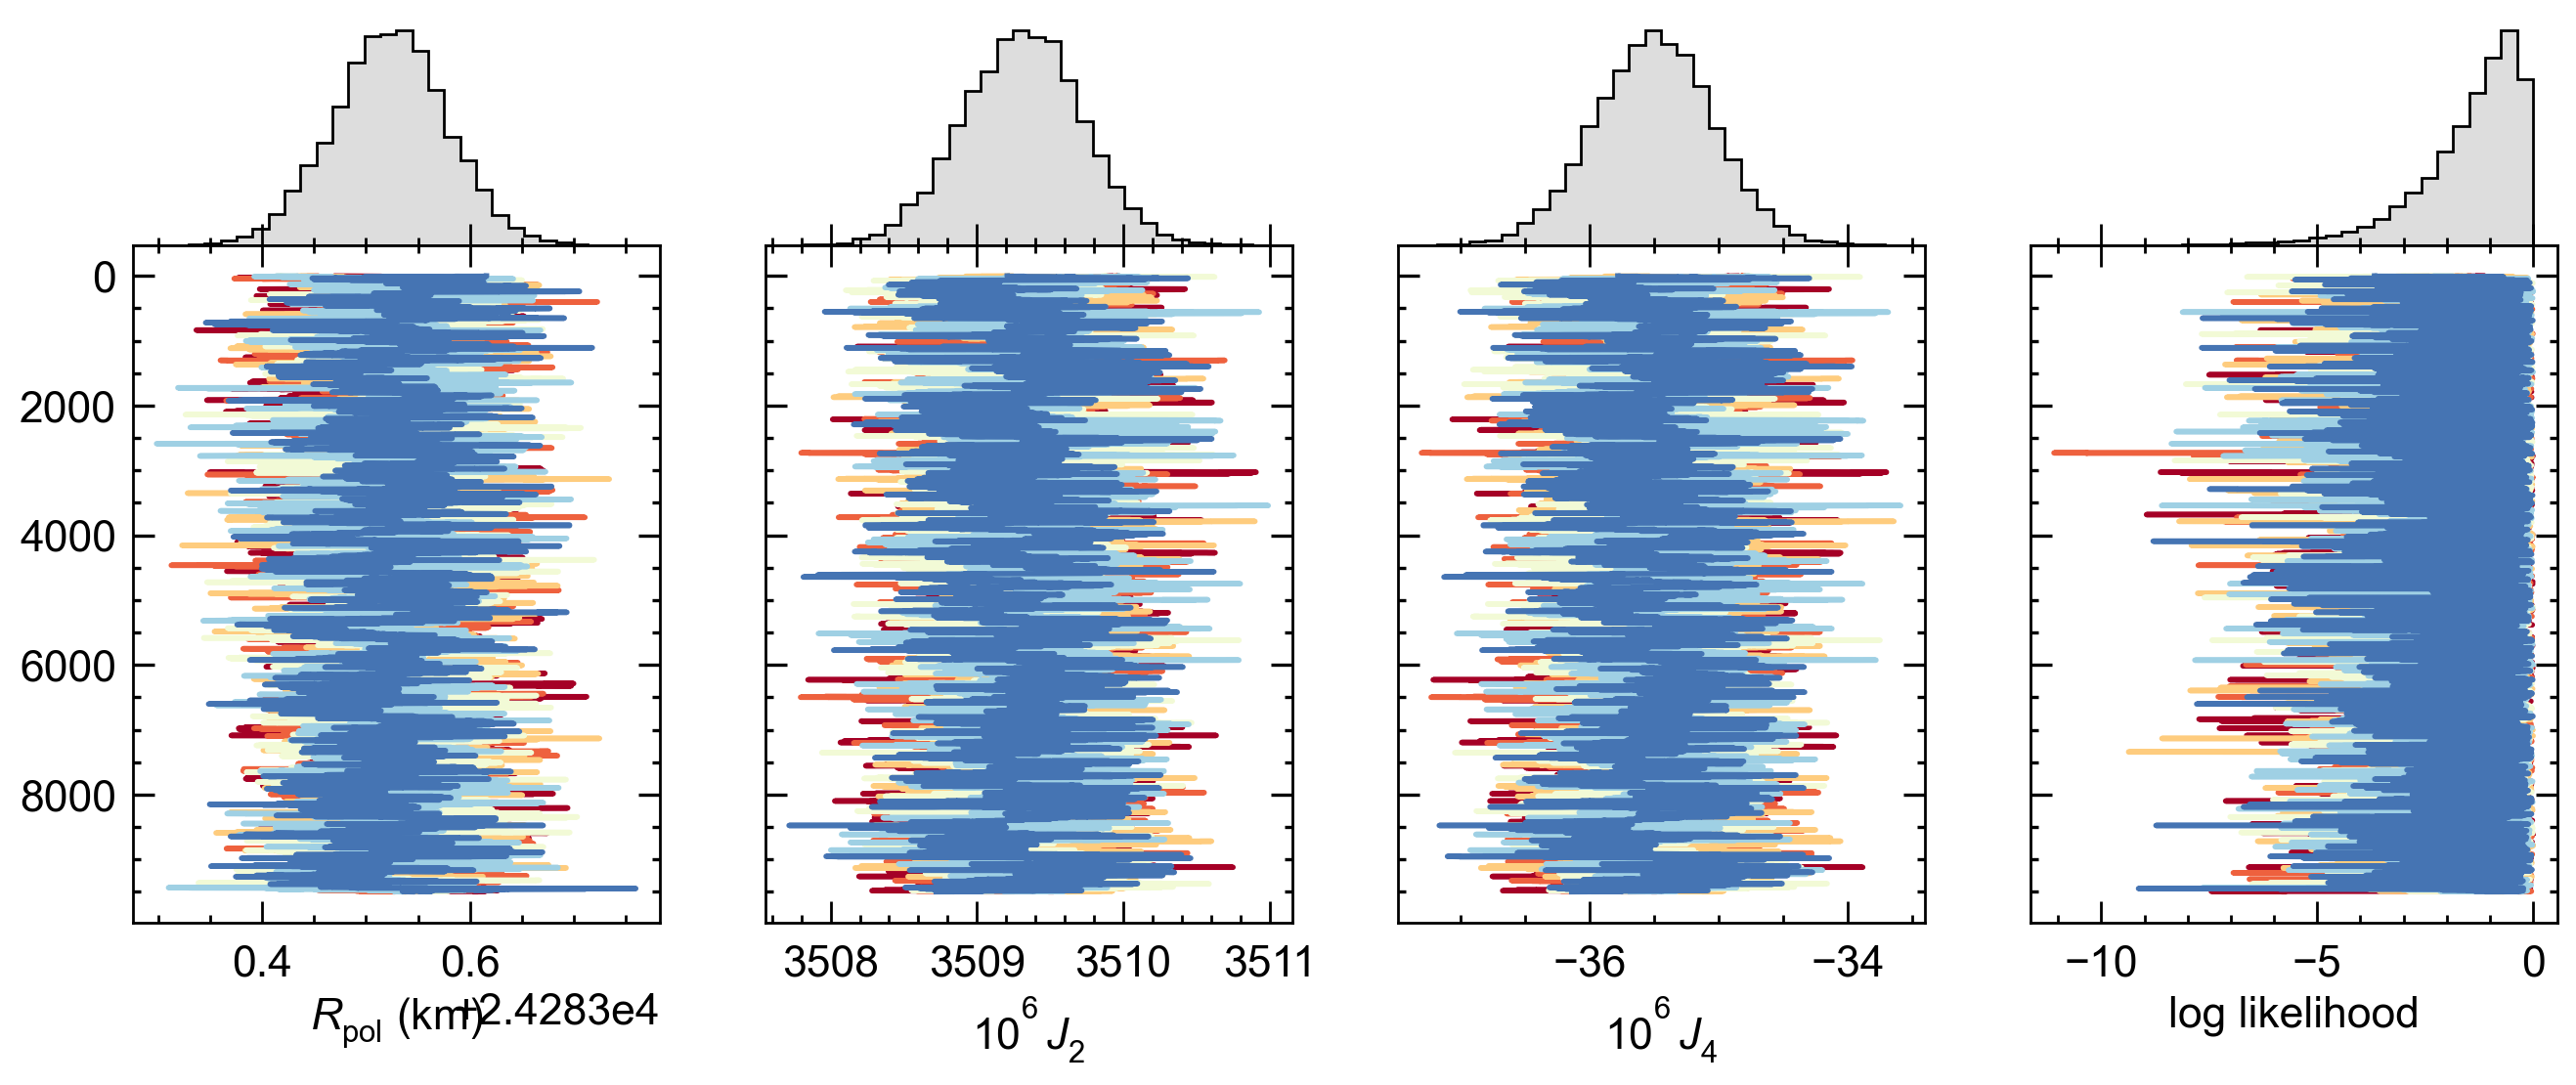

In [12]:
plot_trace(sampler_jn, nburn=500, names=(r'$R_{\rm pol}\ ({\rm km})$', r'$10^6\,J_2$', r'$10^6\,J_4$'), factors=(1e-5, 1e6, 1e6))

rp = sampler_jn.get_chain()[500:, :, 0].flatten()
print(f'vary jn: {np.mean(1e-5 * rp):.3f} +/- {np.std(1e-5 * rp):.3f} km')

In [2]:
# the above mcmc sample varying j2, j4 required a nonzero (50-m) uncertainty on occultation radii to perform well in terms of statistical convergence.
# hence, the ~50-m standard deviation in the r_pol posterior distribution is not really representative of the (tiny) influence of jn, but just reflects the occultation erro we imposed a priori.
# here do the much simpler exercise of starting at the closest occultation point to equator (or pole), randomly drawing j2 and j4 from their Gaussian ellipse, and integrating Equation 3 to equator (or pole).

def sample_jn(nsteps=10000): # asdf
    import mcmc; reload(mcmc)
    import wind_profiles; reload(wind_profiles)
    import geoid
    from occultation_data import neptune as occultation_radii

    omega = wind_profiles.neptune_omega_tot_interpolant(option='voyager')

    # constants for Neptune; Jacobson 2009
    r_ref = 25225e5
    jn = 3408.43e-6, -33.4e-6, 0. # for reference, j2 and j4 uncertainties are 4.5e-6 and 2.9e-6
    gm = 6836527e15

    g = geoid.geoid(24285.8e5, jn, r_ref, gm, omega=omega) # create geoid object just for its grid
    def _dr_dphi(phi, r, jn): # adapted from geoid.geoid
        return r * geoid.gphi_(r, np.sin(phi), *jn, r_ref, gm, omega(phi)) / geoid.gr_(r, np.sin(phi), *jn, r_ref, gm, omega(phi))

    from scipy.integrate import solve_ivp

    re = np.zeros(nsteps)
    rp = np.zeros(nsteps)
    from tqdm import tqdm
    j2 = np.zeros(nsteps)
    j4 = np.zeros(nsteps)
    for i, _jn in tqdm(enumerate(mcmc.gauss_jn_uranus.rvs(nsteps))):
        jn = (*_jn, 0) # tuple of j2, j4, j6

        lat, rocc = occultation_radii['voyager 2 egress']
        # integrate from occultation to equator
        re[i] = solve_ivp(_dr_dphi, np.array([lat * np.pi / 180, 0.]), np.array([rocc*1e5]), args=(jn,), t_eval=np.array([0.]), rtol=1e-8, atol=1e-8).y[0, 0]
        # integrate from occultation to pole
        rp[i] = solve_ivp(_dr_dphi, np.array([lat * np.pi / 180, -np.pi/2]), np.array([rocc*1e5]), args=(jn,), t_eval=np.array([-np.pi/2]), rtol=1e-8, atol=1e-8).y[0, 0]

        j2[i], j4[i] = _jn

    # note, means are close but will not agree perfectly with baseline models, since only one occultation is being fit at a time
    print(1e-5 * np.mean(rp), 1e-5 * np.std(rp))
    print(1e-5 * np.mean(re), 1e-5 * np.std(re))

    return {'rp':rp, 're':re, 'j2':j2, 'j4':j4}

results_sample_jn = sample_jn()

10000it [00:32, 306.13it/s]

24283.51583728615 0.05906720967463972
24763.547839241797 0.0038915360080741734


In [13]:
''' experiment 3: vary r_pol and coefficients in Tollefson+2018 wind fits '''

# the dispersion of the T18 wind coefficients means that variations affect the shape model by a lot.
# hence, assuming a tiny (~50-m) error on the occultation radius makes it too easy to go from a good solution
# to a terrible one, and the sampler slows to a halt with low acceptance fractions.
# here assume the realistic 5-km uncertainty on the occultation radius. as we will see, the posterior spread 
# in r_pol will be 1-2 orders of magnitude larger anyway due to the uncertain winds.

import mcmc; reload(mcmc)
import wind_profiles; reload(wind_profiles)

# we'll loop through wind fits. store samplers in a dictionary
samplers_vary_wind = {}

# constants for Neptune; Jacobson 2009
r_ref = 25225e5
jn = 3408.43e-6, -33.4e-6, 0. # for reference, j2 and j4 uncertainties are 4.5e-6 and 2.9e-6
gm = 6836527e15

for wind_option, _ in wind_options.items():

    # create starting position for emcee sampler and check it has finite lnp
    ndim = 1 + 3 # 3 params for a, b, c cofficients in T18's 4th-order polynomials in Table 1
    nwalk = 2 * ndim

    theta0 = np.zeros((nwalk, ndim))
    theta0[:, 0] = 2.5e9 * (1. + np.random.rand(nwalk) * 1e-1) # r_pol # 1% spread around arbitrary starting guess
    theta0[:, 1:] = mcmc.gauss_norm.rvs(nwalk) # draw wind fit coefficients from the Gaussian prior
    print('starting position:')
    print(theta0)

    print('starting lnp:')
    isafety = 0
    for iw, theta in enumerate(theta0):
        lnp, blob = mcmc.lnp_vary_wind(theta, jn, r_ref, gm, debug=True, planet='neptune', wind_option=wind_option)
        assert not np.isinf(lnp), f'got infinite lnp for r_pol guess {theta[0]*1e-9:.5f}'
        print(lnp)

    import emcee
    from multiprocessing import Pool

    print('sampling:')
    # nsteps = 10
    # nsteps = 300
    nsteps = 10000
    with Pool() as pool:
        samplers_vary_wind[wind_option] = emcee.EnsembleSampler(
            nwalkers=nwalk,
            ndim=ndim,
            log_prob_fn=mcmc.lnp_vary_wind,
            pool=pool, # comment out to do it serially. using multiprocessing.Pool is giving me ~37 it/s compared to ~22 it/s serially
            args=(jn, r_ref, gm),
            # kwargs={'debug':False,'sigma_rocc_km':0.05, 'planet':'neptune', 'wind_option':wind_option,} # make the RO uncertainty near-negligible at 50 meters to isolate the effect of uncertain winds
            kwargs={'debug':False,'sigma_rocc_km':5, 'planet':'neptune', 'wind_option':wind_option,} 
        )

        samplers_vary_wind[wind_option].run_mcmc(
            initial_state=theta0,
            nsteps=nsteps,
            progress=True,
        )

    print(samplers_vary_wind[wind_option].acceptance_fraction)


starting position:
[[ 2.55368682e+09  1.16085690e+00  5.07439104e-01  1.54963647e+00]
 [ 2.69877317e+09  1.29066744e+00  3.77771262e-01 -1.98442015e-01]
 [ 2.50593619e+09  6.36289989e-01  6.46716724e-01  5.36796988e-01]
 [ 2.69904062e+09  2.48204859e-02  6.67505852e-01  2.98376410e+00]
 [ 2.66012138e+09  5.45010143e-01 -1.79242580e+00  1.25932565e-01]
 [ 2.58455039e+09 -4.10304395e-01  2.19842819e+00  9.03421392e-02]
 [ 2.69246913e+09  4.38359938e-01  6.38479676e-01  3.84965266e-01]
 [ 2.60675421e+09  1.01047657e+00  2.57419504e+00  7.32504395e-01]]
starting lnp:
-37309.643805232816
-160000.9161439558
-13996.170909809161
-177319.8748910668
-111560.68534461987
-57655.245854734596
-156042.1703824501
-77831.45139525074
sampling:


100%|██████████| 10000/10000 [10:38<00:00, 15.65it/s]


[0.5857 0.5907 0.585  0.5857 0.5879 0.5922 0.5921 0.5905]
starting position:
[[ 2.70452024e+09  5.48746951e-01  2.96987232e-01  1.80548932e+00]
 [ 2.50328682e+09  6.94864891e-01 -3.04366235e-01  1.66138358e+00]
 [ 2.57122221e+09  8.24056911e-01  2.18373368e+00  2.01769032e+00]
 [ 2.66615734e+09 -1.10764535e+00  1.61889247e+00  2.02799222e+00]
 [ 2.65485285e+09  4.82319381e-01  2.60076264e-01  6.57709829e-01]
 [ 2.50074250e+09  1.60166818e+00 -3.64913647e-01  3.09083618e+00]
 [ 2.69837362e+09  3.21418956e+00  2.96824485e+00  1.82207737e+00]
 [ 2.74775524e+09  1.24779397e+00  2.51375826e+00 -1.31142799e+00]]
starting lnp:
-204920.68111189446
-16455.56029930859
-93642.12153000674
-188286.3798109329
-119645.72058334756
-24998.769998070344
-309008.5054124086
-242200.36984107885
sampling:


100%|██████████| 10000/10000 [21:00<00:00,  7.94it/s]


[0.3947 0.3943 0.4004 0.4091 0.4133 0.4288 0.4027 0.4166]


vary wind: voyager: 24234.46 +/- 36.77 km
vary wind: h-band 2014: 24075.38 +/- 171.38 km


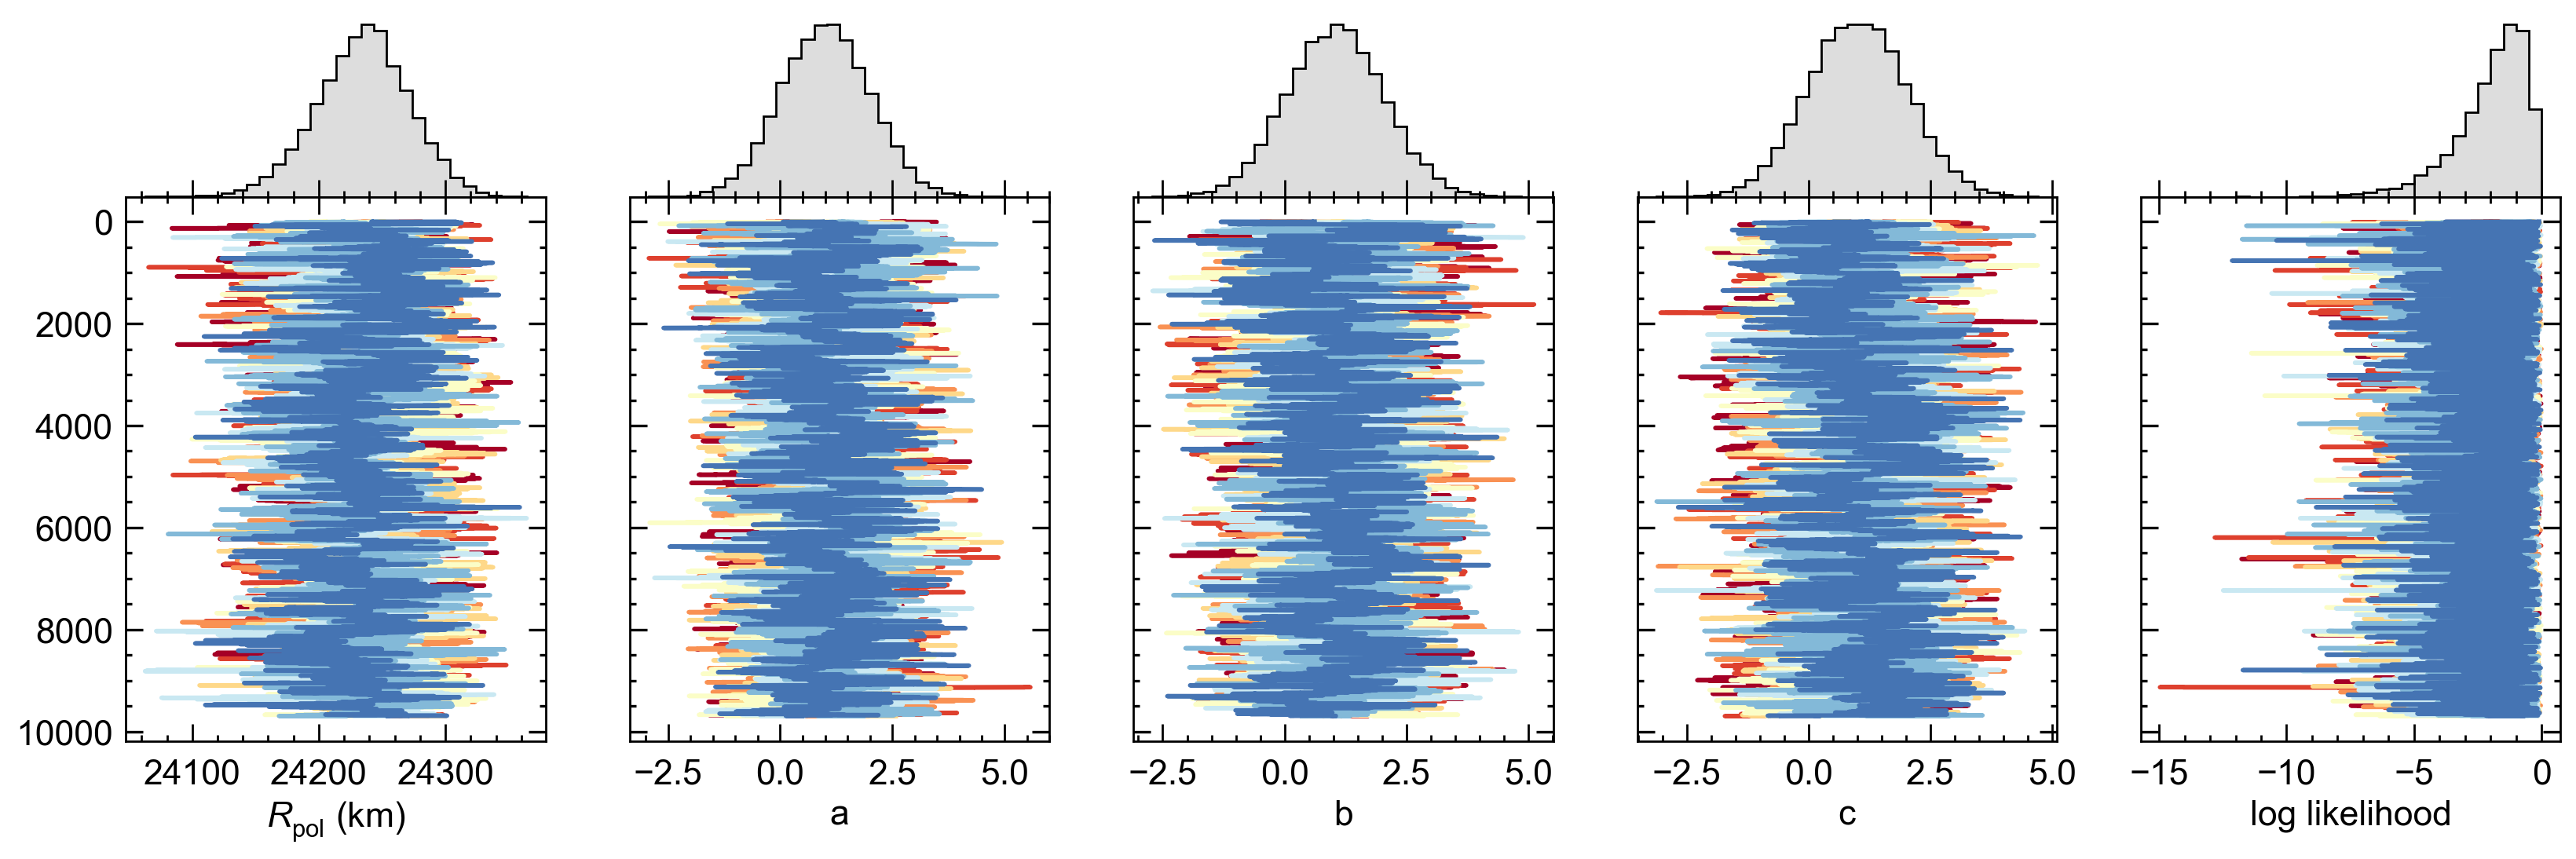

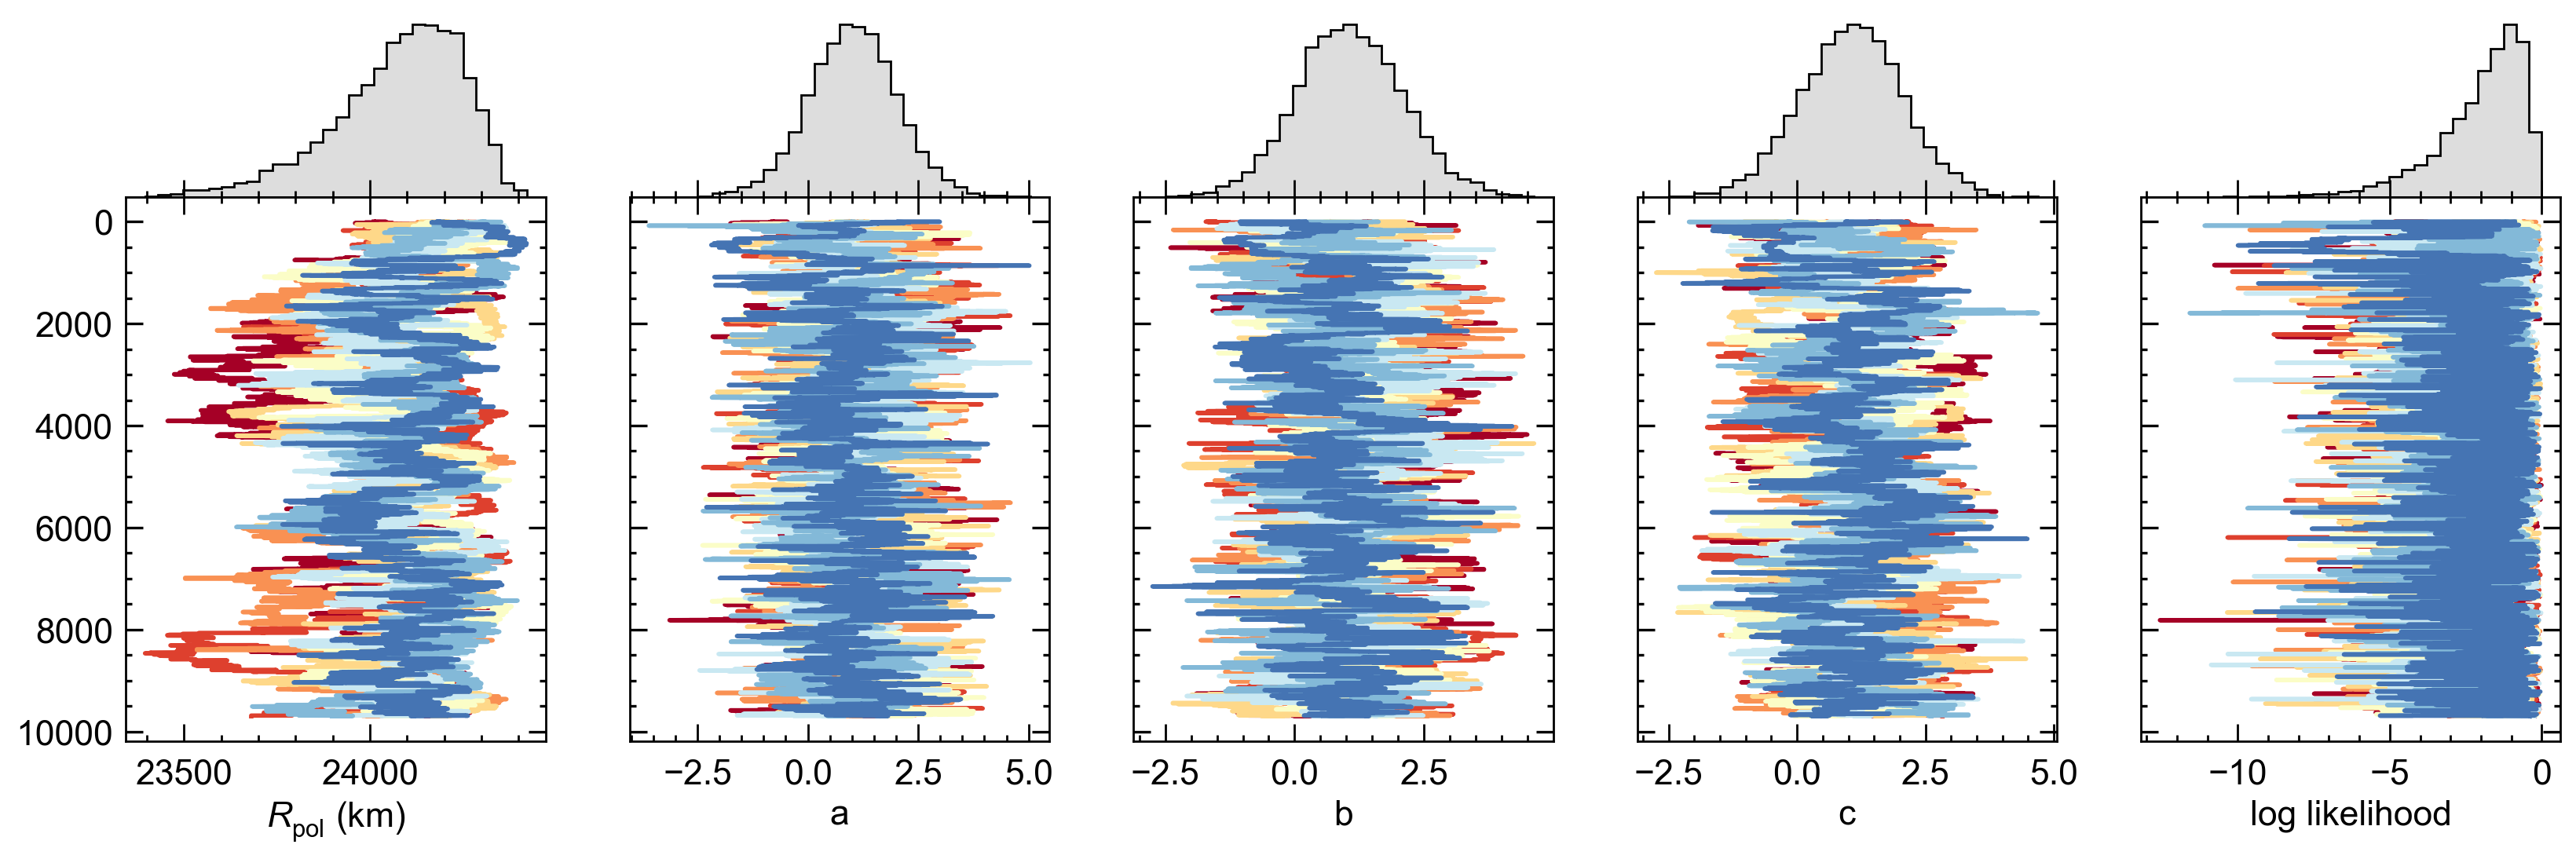

In [14]:
nburn = 300
for wind_option, sampler in samplers_vary_wind.items():
    plot_trace(sampler, nburn=nburn, names=(r'$R_{\rm pol}\ (\rm km)$','a','b', 'c'), factors=(1e-5,))

    rp = sampler.get_chain()[nburn:, :, 0].flatten()
    print(f'vary wind: {wind_option}: {np.mean(1e-5 * rp):.2f} +/- {np.std(1e-5 * rp):.2f} km')

voyager: pole: $24234.5\pm36.8$ km
voyager: equator: $24763.5\pm5.3$ km
h-band 2014: pole: $24075.4\pm171.4$ km
h-band 2014: equator: $24778.8\pm7.7$ km


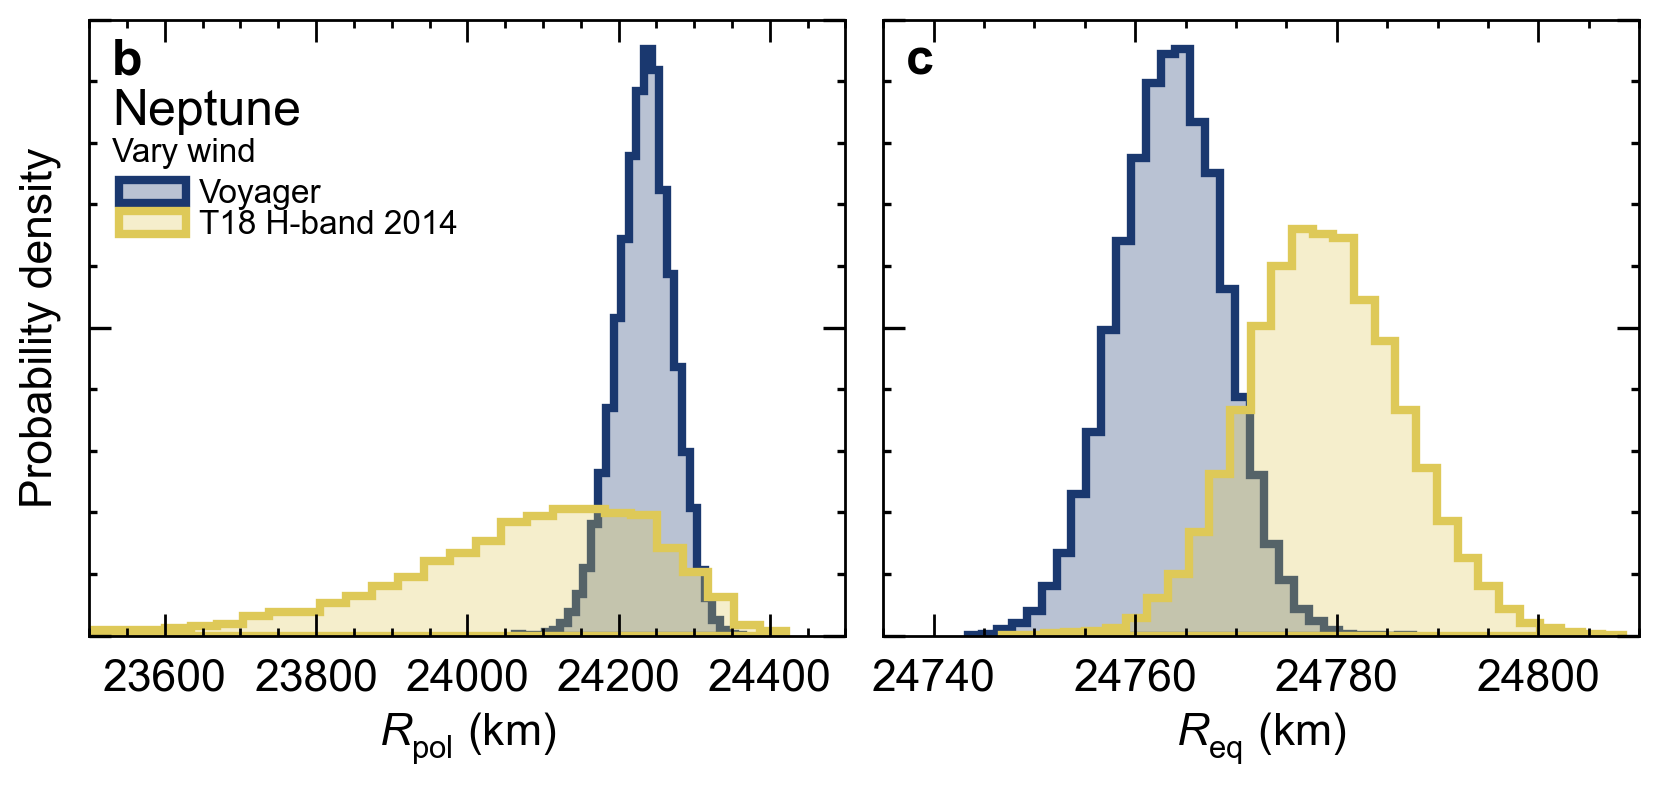

In [64]:
# Figure 5b-c, distributions of Neptune radii for two wind profiles with sampled polynomial coefficients
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})
nburn = 300
for iwind, (wind_option, s) in enumerate(samplers_vary_wind.items()):
    color = wind_options[wind_option]['color']
    label = wind_options[wind_option]['label']
    
    rp = np.array([g.r[0] for g in s.get_blobs()[nburn:, :].flatten()])
    re = np.array([g.r[len(g.mu) // 2] for g in s.get_blobs()[nburn:, :].flatten()])

    ax[0].hist(1e-5 * rp, histtype='stepfilled', density=True, edgecolor=color, facecolor=(*color[:-1], 0.3), bins=30, zorder=0, lw=3, label=label)
    ax[1].hist(1e-5 * re, histtype='stepfilled', density=True, edgecolor=color, facecolor=(*color[:-1], 0.3), bins=30, zorder=0, lw=3, label=label)
    print(rf'{wind_option}: pole: ${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km')
    print(rf'{wind_option}: equator: ${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km')

for z in ax:
    yl = z.get_ylim()
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=2, bbox_to_anchor=(0, 0.79))

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Probability density')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
ax[0].set_xlim(23500, 24500)
ax[1].set_xlim(24735, 24810)
ax[0].text(0.03, 0.83, 'Neptune', fontsize=18, transform=ax[0].transAxes)
ax[0].text(0.03, 0.77, 'Vary wind', fontsize=12, transform=ax[0].transAxes)
for iax, c in enumerate('bc'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

plt.savefig('figures/neptune_radii_vary_wind.pdf')

In [51]:
asdf = *color[:-1], 0.2
print(asdf)

(np.float64(0.870717), np.float64(0.789572), np.float64(0.343333), 0.2)


voyager: pole: $24285.8\pm4.9$ km
voyager: equator: $24761.9\pm5.2$ km
h-band 2014: pole: $24311.6\pm4.9$ km
h-band 2014: equator: $24769.4\pm5.2$ km


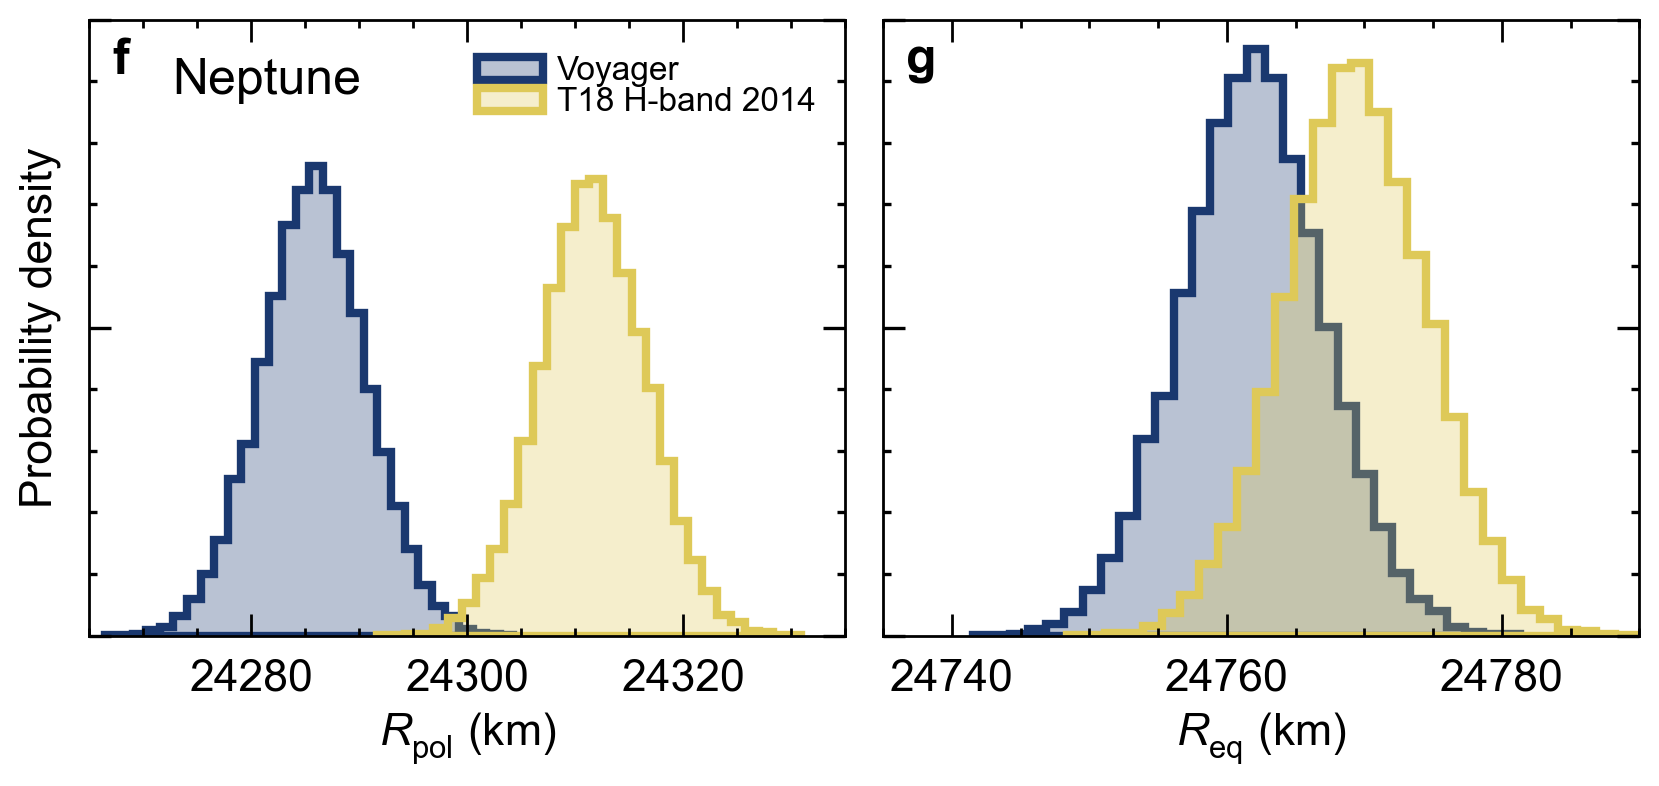

In [62]:
# Figure 5f-g, distributions of Neptune radii for two fixed wind profiles -- only r_pol varies
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.05})
for iwind, (wind_option, s) in enumerate(samplers.items()):

    color = wind_options[wind_option]['color']
    label = wind_options[wind_option]['label']

    rp = np.array([g.r[0] for g in s.get_blobs()[nburn:, :].flatten()])
    re = np.array([g.r[len(g.mu) // 2] for g in s.get_blobs()[nburn:, :].flatten()])
    
    ax[0].hist(1e-5 * rp, histtype='stepfilled', density=True, edgecolor=color, facecolor=(*color[:-1], 0.3), bins=30, zorder=0, lw=3, label=label)
    ax[1].hist(1e-5 * re, histtype='stepfilled', density=True, edgecolor=color, facecolor=(*color[:-1], 0.3), bins=30, zorder=0, lw=3, label=label)

    print(rf'{wind_option}: pole: ${np.mean(rp*1e-5):.1f}\pm{np.std(rp*1e-5):.1f}$ km')
    print(rf'{wind_option}: equator: ${np.mean(re*1e-5):.1f}\pm{np.std(re*1e-5):.1f}$ km')

for iax, z in enumerate(ax):
    yl = np.array(z.get_ylim())
    if iax == 0: 
        yl *= 1.25
    z.set_yticks([0, yl[1] / 2, yl[1]], minor=False)
    z.set_yticks(np.linspace(0, yl[1], 11), minor=True)
    z.set_ylim(*yl)

ax[0].legend(fontsize=12, loc=1, bbox_to_anchor=(1, 0.99))

ax[0].set_xlabel(r'$R_{\rm pol}$ (km)')
ax[1].set_xlabel(r'$R_{\rm eq}$ (km)')
ax[0].set_ylabel(r'Probability density')
# plt.gca().yaxis.set_ticks([0, yl[1]/2, yl[1]], minor=False)
[z.tick_params(labelleft=False) for z in ax]
# ax[0].set_xlim(23800, 24500)
ax[0].set_xlim(24265, 24335)
ax[1].set_xlim(24735, 24790)
ax[0].text(0.11, 0.88, 'Neptune',                fontsize=18, ha='left', transform=ax[0].transAxes)
# ax[0].text(0.11, 0.82, r'$R_{\rm occ}$ uncertainty only',    fontsize=12, ha='left', transform=ax[0].transAxes)
for iax, c in enumerate('fg'):
    ax[iax].text(0.03, 0.97, c, weight='bold', fontsize=18, ha='left', va='top', transform=ax[iax].transAxes)

# fig.suptitle(r'Vary $R_{\rm occ}$')
plt.savefig('figures/neptune_radii_vary_ro.pdf')

In [ ]:
''' save some output '''

import pathlib
pathlib.Path('models/statistical_samples/neptune_voyager' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_h-band_2014' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_vary_wind_voyager' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_vary_wind_h-band_2014' ).mkdir(exist_ok=True, parents=True)
pathlib.Path('models/statistical_samples/neptune_vary_jn'   ).mkdir(exist_ok=True, parents=True)

if False: # save the emcee.EnsembleSampler objects as pickled python dictionaries, ~15 GB. not very interoperable but possibly convenient in the short term.
    import dill as pickle
    for wind_option, sampler in samplers.items(): # runs with fixed winds (vary only r_pol)
        with open(f'/tmp/neptune_sampler_{wind_option}.pkl', 'wb') as fw:
            pickle.dump(sampler, fw)
    with open('/tmp/neptune_sampler_jn.pkl', 'wb') as fw: # run that varied r_pol, j2, j4
        pickle.dump(sampler_jn, fw)
    for wind_option, sampler in samplers_vary_wind.items(): # runs with variable winds (vary r_pol and coeffs in wind fit)
        with open(f'/tmp/neptune_sampler_wind_{wind_option}.pkl', 'wb') as fw:
            pickle.dump(sampler, fw)
    
# save mcmc chains to plaintext, including log posterior probability and equatorial and polar radii.

outfile = 'models/statistical_samples/neptune_voyager_chain.txt'
blobs = samplers['voyager'].get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = samplers['voyager'].get_log_prob().flatten()
header  = "polar and equatorial radii for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'lnp':>16} "
fmt = ('%5i', '%16.3f', '%16.3f', '%16.3e')
np.savetxt(outfile, np.array([index, rp_km, re_km, lnp]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/neptune_h-band_2014_chain.txt'
blobs = samplers['h-band 2014'].get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rn_km = np.array([1e-5 * g.r[ 0] for g in blobs])
rs_km = np.array([1e-5 * g.r[-1] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = samplers['h-band 2014'].get_log_prob().flatten()
header  = "polar and equatorial radii for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric H-band 2014 wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
header += f"{'index':>5} {'r_pol_north_km':>16} {'r_pol_south_km':>16} {'r_eq_km':>16} {'lnp':>16}"
fmt = ('%5i', '%16.3f', '%16.3f', '%16.3f', '%16.3e')
np.savetxt(outfile, np.array([index, rn_km, rs_km, re_km, lnp]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/neptune_vary_jn.txt'
# blobs = sampler_jn.get_blobs().flatten()
# index = np.array([i for i, g in enumerate(blobs)])
# rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
# re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
# lnp = sampler_jn.get_log_prob().flatten()
# j2 = sampler_jn.get_chain()[:, :, 0].flatten()
# j4 = sampler_jn.get_chain()[:, :, 1].flatten()
index = np.arange(len(results_sample_jn['rp']))
rp_km = 1e-5 * results_sample_jn['rp']
re_km = 1e-5 * results_sample_jn['re']
j2 = results_sample_jn['j2']
j4 = results_sample_jn['j4']
header  = "polar and equatorial radii for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
header += 'the polar and equatorial radii in this file come from random draws in j2 and j4 from the Jacobson (2009, AJ 137) error ellipsoid,\n'
header += 'followed by direct integration of Equation (3) from the Voyager 2 occultation point reported in Lindal (1992, AJ 103) to either the equator or the pole.\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'j2':>16} {'j4':>16}"
fmt = ('%5i', '%16.5f', '%16.5f', '%16.8e', '%16.8e')
np.savetxt(outfile, np.array([index, rp_km, re_km, j2, j4]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/neptune_vary_wind_voyager.txt'
blobs = samplers_vary_wind['voyager'].get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = samplers_vary_wind['voyager'].get_log_prob().flatten()
abc = np.array([samplers_vary_wind['voyager'].get_chain()[:, :, idim].flatten() * np.sqrt(mcmc.gauss_t18_voy.cov.diagonal()[idim-1]) + mcmc.gauss_t18_voy.mean[idim-1] for idim in 1 + np.arange(3)])
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
header += 'these solutions vary the polar radius to fit the Voyager 2 radio occultation to a Gaussian with standard deviation 5 km.\n'
header += 'the wind fit polynomial coefficients a, b, and c are also allowed to vary within their Gaussian uncertainties following T18 Table 1.\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'a':>16} {'b':>16} {'c':>16} {'lnp':>16} "
fmt = ('%5i', '%16.3f', '%16.3f', '%16.6f', '%16.6e', '%16.6e', '%16.3e')
np.savetxt(outfile, np.array([index, rp_km, re_km, *abc, lnp]).T, fmt=fmt, header=header, comments='')

outfile = 'models/statistical_samples/neptune_vary_wind_h-band_2014.txt'
blobs = samplers_vary_wind['h-band 2014'].get_blobs().flatten()
index = np.array([i for i, g in enumerate(blobs)])
rp_km = np.array([1e-5 * g.r[ 0] for g in blobs])
re_km = np.array([1e-5 * g.r[len(g.mu) // 2] for g in blobs])
lnp = samplers_vary_wind['h-band 2014'].get_log_prob().flatten()
abc = np.array([samplers_vary_wind['h-band 2014'].get_chain()[:, :, idim].flatten() * np.sqrt(mcmc.gauss_t18_h14.cov.diagonal()[idim-1]) + mcmc.gauss_t18_h14.mean[idim-1] for idim in 1 + np.arange(3)])
header  = "polar and equatorial radii for Uranus's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
header += 'the models summarized in this file assume the symmetric H-band 2014 wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
header += 'these solutions vary the polar radius to fit the Voyager 2 radio occultation to a Gaussian with standard deviation 5 km.\n'
header += 'the wind fit polynomial coefficients a, b, and c are also allowed to vary within their Gaussian uncertainties following T18 Table 1.\n'
header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16} {'a':>16} {'b':>16} {'c':>16} {'lnp':>16} "
fmt = ('%5i', '%16.3f', '%16.3f', '%16.6f', '%16.6e', '%16.6e', '%16.3e')
np.savetxt(outfile, np.array([index, rp_km, re_km, *abc, lnp]).T, fmt=fmt, header=header, comments='')

# detailed model output saved to plaintext for a small number of models
n_models_each_type = 32
for i in np.arange(n_models_each_type):
    g = samplers['voyager'].get_blobs().flatten()[-i] # count back from the end
    outfile = f'models/statistical_samples/neptune_voyager/neptune_voyager_{i:02}.txt'
    header  = "shape model output for Neptunes's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
    header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = samplers['h-band 2014'].get_blobs().flatten()[-i] # count back from the end
    outfile = f'models/statistical_samples/neptune_h-band_2014/neptune_h-band_2014_{i:02}.txt'
    header  = "shape model output for Neptunes's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'this model assumes the H-band 2014 wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
    header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = samplers_vary_wind['voyager'].get_blobs().flatten()[-i]
    outfile = f'models/statistical_samples/neptune_vary_wind_voyager/neptune_vary_wind_voyager_{i:02}.txt'
    header  = "shape model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models summarized in this file assume the symmetric Voyager wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
    header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
    header += 'these solutions vary the polar radius to fit the Voyager 2 radio occultation to a Gaussian with standard deviation 5 km.\n'
    header += 'the wind fit polynomial coefficients are also allowed to vary within their Gaussian uncertainties following T18 Table 1.\n'
    header += f'this model has wind polynomial cofficients a, b, c: '
    for n in range(3):
        # a, b, and c are each regularized (subtract mean and divide by standard deviation) for sampling; restore to original meaning here
        header += f'{samplers_vary_wind['voyager'].get_chain()[:, :, 1 + n].flatten()[-i] * np.sqrt(mcmc.gauss_t18_voy.cov.diagonal()[n]) + mcmc.gauss_t18_voy.mean[n] :16.6e}'
    header += '\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')

    g = samplers_vary_wind['h-band 2014'].get_blobs().flatten()[-i]
    outfile = f'models/statistical_samples/neptune_vary_wind_h-band_2014/neptune_vary_wind_h-band_2014_{i:02}.txt'
    header  = "shape model output for Neptune's 1-bar isobaric surface. models are described in Mankovich et al. 2026, PSJ.\n"
    header += 'the models summarized in this file assume the symmetric H-band 2014 wind profile from Tollefson et al. (2018, Icarus 311) Table 1.\n'
    header += 'the distribution of models in this file comes from Markov chain Monte Carlo fits to the Voyager 2 radio occultation reported in Lindal (1992, AJ 103).\n'
    header += 'these solutions vary the polar radius to fit the Voyager 2 radio occultation to a Gaussian with standard deviation 5 km.\n'
    header += 'the wind fit polynomial coefficients are also allowed to vary within their Gaussian uncertainties following T18 Table 1.\n'
    header += f'this model has wind polynomial cofficients a, b, c: '
    for n in range(3):
        # a, b, and c are each regularized (subtract mean and divide by standard deviation) for sampling; restore to original meaning here
        header += f'{samplers_vary_wind['voyager'].get_chain()[:, :, 1 + n].flatten()[-i] * np.sqrt(mcmc.gauss_t18_h14.cov.diagonal()[n]) + mcmc.gauss_t18_h14.mean[n] :16.6e}'
    header += '\n'
    header += 'mu=sin(phi), phi [radians], and lat_deg [degrees] refer to planetocentric latitude; lat_pg_deg gives planetographic latitude in degrees.\n'
    # header += f"{'index':>5} {'r_pol_km':>16} {'r_eq_km':>16}"
    fmt = '%16.10f'
    names = 'mu', 'phi_rad', 'lat_deg', 'lat_pg_deg', 'psi_rad', 'omega_rad_s-1', 'r_km'
    for name in names:
        header += f"{name:>16} "
    data = np.array([g.mu, g.phi, g.lat, g.planetographic_latitude, g.psi, g.omega, 1e-5 * g.r]).T
    np.savetxt(outfile, data, fmt=fmt, header=header, comments='')
